# Optimización Combinatoria: Espacios Discretos y Permutaciones

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/05_algoritmos_geneticos/04_optimizacion_combinatoria.ipynb)

## Objetivos


- Comprender por qué los operadores matemáticos continuos fallan en espacios discretos.
- Dominar la **Codificación Binaria** resolviendo el Problema de la Mochila (*Knapsack Problem*).
- Aprender a manejar **Restricciones (*Constraints*)** mediante funciones de penalización.
- Dominar la **Codificación Permutacional** resolviendo el Problema del Viajante de Comercio (*TSP*).
- Entender e implementar operadores especializados que preservan la validez estructural (Cruce OX y Mutación por Inversión).



## Prerrequisitos


- Haber completado: [Introducción a DEAP: Infraestructura Evolutiva en Python](03_framework_deap_y_paralelizacion.ipynb).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import random

# Instalación de DEAP, no está presente en Colab
try:
    import deap
except ImportError:
    !pip install deap
    import deap

from deap import base, creator, tools, algorithms

# Fijamos la semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 268.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 15.9 MB/s eta 0:00:00


## Introducción Teórica: El Salto a lo Discreto



Hasta ahora, nuestros Algoritmos Genéticos han vivido en el mundo de los números reales ($x \in \mathbb{R}^D$). Si teníamos dos padres, $p_1 = 2.0$ y $p_2 = 4.0$, podíamos crear un hijo promediándolos: $h = 3.0$.

Pero en la ingeniería real, muchas decisiones son **discretas**:
* *¿Incluyo este sensor en el diseño final o no?* (1 o 0).
* *¿En qué orden deben visitar las máquinas los técnicos de mantenimiento?* (Permutaciones).

¿Qué pasa si intentamos usar un Cruce Aritmético aquí? No podemos visitar la ciudad "2,5", ni podemos instalar "0,8" de un sensor. La matemática continua se rompe. Necesitamos **operadores especializados** que respeten la naturaleza del problema.

En este notebook, exploramos los dos grandes mundos de la optimización combinatoria: la **Representación Binaria** y la **Representación Permutacional**.

> **NOTA**: Existen otras representaciones avanzadas en la industria, como la **Entera** para variables categóricas, la representación en **Árbol** (que vemos en Programación Genética dentro de poco), o en **Grafos** para topologías de redes, pero dominando las binarias y permutacionales tenemos las bases para entender el resto.

## Parte I: Representación Binaria y el Manejo de Restricciones


### 1. El Problema de la Mochila (*Knapsack Problem*)



Es el "Hola Mundo" de la optimización binaria. Imaginemos que somos un explorador. Tenemos una mochila que soporta un peso máximo $W_{max}$. Frente nuestro hay $N$ objetos, cada uno con un **peso** y un **valor**. El objetivo es seleccionar un subconjunto de objetos que maximice el valor total, sin que la mochila se rompa por exceso de peso.

* **Genotipo:** Un vector de $N$ bits (ej. `[1, 0, 1, 1, 0]`). Un `1` significa que llevamos el objeto, un `0` que lo dejamos.
* **Espacio de búsqueda:** $2^N$ combinaciones posibles.

Vamos a generar un dataset sintético de 50 objetos.

In [2]:
N_OBJETOS = 50
PESO_MAXIMO = 250

# Generamos pesos y valores aleatorios para los 50 objetos
pesos = np.random.randint(1, 20, N_OBJETOS)
valores = np.random.randint(10, 100, N_OBJETOS)

print(f"Capacidad de la mochila: {PESO_MAXIMO} kg")
print(f"Pesos de los primeros 5 objetos: {pesos[:5]}")
print(f"Valores de los primeros 5 objetos: {valores[:5]}")

Capacidad de la mochila: 250 kg
Pesos de los primeros 5 objetos: [ 7 15 11  8  7]
Valores de los primeros 5 objetos: [15 63 13 63 72]


### 2. El Criterio de Ingeniería: ¿Cómo manejamos las restricciones?



¿Qué pasa si el GA genera un individuo (una mochila) que pesa 255 kg? La solución es inválida. Tenemos dos opciones para diseñar nuestra función de fitness:

1. ⚠️ **La "Pena de Muerte" (Hard Penalty):** Si se pasa del peso, le asignamos un fitness de $0$.
   * *Por qué es una mala idea:* Si la mochila pesa 251 kg, el GA la descarta igual que si pesara 5000 kg. Destruimos información valiosa. El algoritmo pierde el "gradiente" que le indica que estaba cerca de una buena solución.
2. ✅ **La "Penalización Suave" (Soft Penalty):** Le restamos puntos al valor total por cada kilo extra.
   * *Por qué es la forma correcta:* Permite que el GA explore temporalmente zonas inválidas para cruzar hacia zonas válidas mejores.

Vamos a programar ambas y a **demostrar empíricamente** cuál es mejor. (Por supuesto, el camino a seguir siempre lo dicta el contexto y entender bien la problemática que estamos resolviendo. *No casarse con una solución para todo...*)

In [3]:
def evaluar_mochila_hard(individuo):
    peso_total = np.sum(individuo * pesos)
    if peso_total > PESO_MAXIMO:
        return (0,) # Pena de muerte
    return (np.sum(individuo * valores),)

def evaluar_mochila_soft(individuo):
    peso_total = np.sum(individuo * pesos)
    valor_total = np.sum(individuo * valores)
    if peso_total > PESO_MAXIMO:
        # Penalización Suave: Restamos un valor proporcional al exceso
        exceso = peso_total - PESO_MAXIMO
        # Penalización proporcional al exceso
        # El "secreto" está en asegurar que las soluciones
        # inválidas siempre sean peores que las válidas
        # El factor sería un hiperparámetro a explorar bajo esta filosofía
        return (valor_total - (exceso * 50),)
    return (valor_total,)

### 3. Implementación en DEAP



Para genes binarios, los operadores ideales son el **Cruce de Dos Puntos** (`cxTwoPoint`) y la **Mutación de Inversión de Bit** (`mutFlipBit`).

Vamos a correr el mismo Algoritmo Genético con ambas funciones de evaluación (*soft* y *hard*) para ver qué sucede.

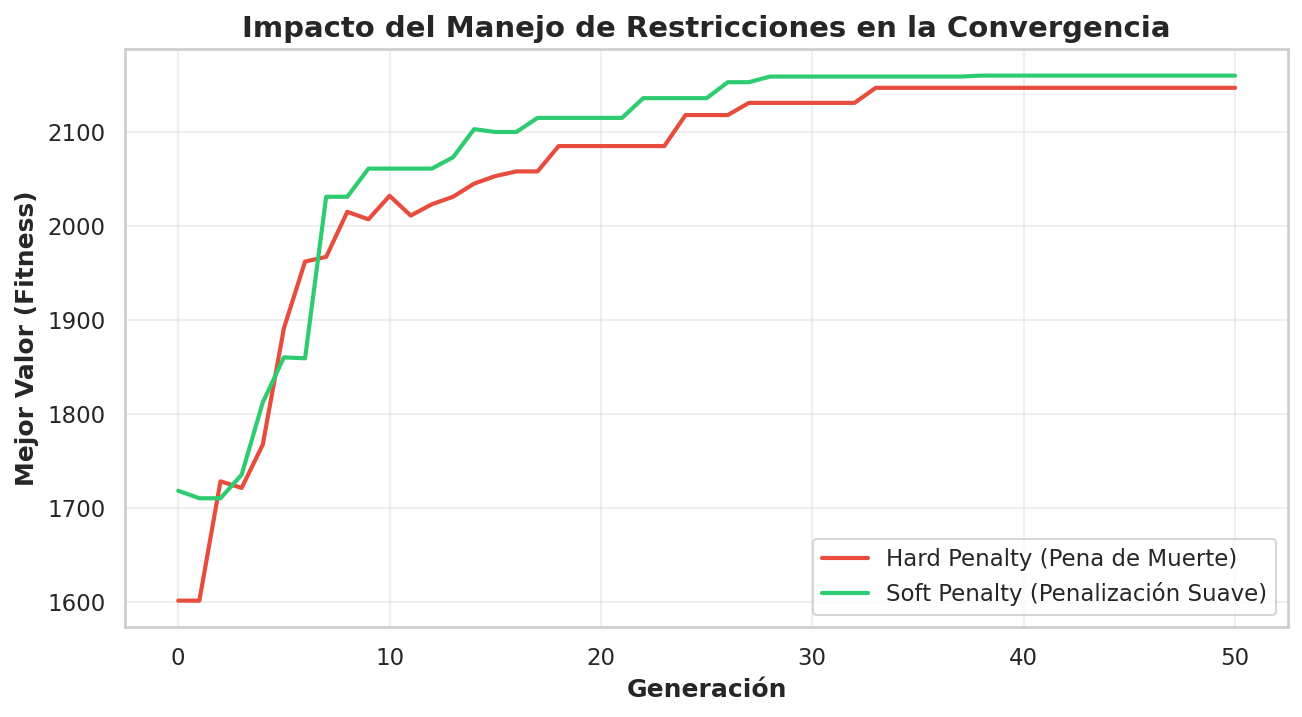

In [4]:
def correr_ga_mochila(funcion_evaluacion):
    # Limpiamos el entorno
    for cls in ['FitnessMax', 'Individual']:
        if hasattr(creator, cls): delattr(creator, cls)

    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    tb = base.Toolbox()
    # Generador de genes: 0 o 1 aleatorio
    tb.register("attr_bool", random.randint, 0, 1)
    tb.register("individual", tools.initRepeat, creator.Individual, tb.attr_bool, n=N_OBJETOS)
    tb.register("population", tools.initRepeat, list, tb.individual)

    # Operadores
    tb.register("evaluate", funcion_evaluacion)
    tb.register("mate", tools.cxTwoPoint)
    # indpb = 1.0 / N_OBJETOS garantiza que, en promedio, mute 1 bit por individuo
    tb.register("mutate", tools.mutFlipBit, indpb=1.0/N_OBJETOS)
    tb.register("select", tools.selTournament, tournsize=3)

    # Estadísticas
    stats = tools.Statistics(key=lambda ind: ind.fitness.values[0])
    stats.register("max", np.max)
    hof = tools.HallOfFame(1)

    pob = tb.population(n=100)
    pob, log = algorithms.eaSimple(pob, tb, cxpb=0.8, mutpb=0.2, ngen=50,
                                   stats=stats, halloffame=hof, verbose=False)
    return log.select("max"), hof[0]

# Ejecutamos ambos experimentos
hist_hard, mejor_hard = correr_ga_mochila(evaluar_mochila_hard)
hist_soft, mejor_soft = correr_ga_mochila(evaluar_mochila_soft)

# Visualización de la convergencia
plt.figure(figsize=(10, 5))
plt.plot(hist_hard, label='Hard Penalty (Pena de Muerte)', color='#e74c3c', lw=2)
plt.plot(hist_soft, label='Soft Penalty (Penalización Suave)', color='#2ecc71', lw=2)
plt.title("Impacto del Manejo de Restricciones en la Convergencia")
plt.xlabel("Generación")
plt.ylabel("Mejor Valor (Fitness)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Análisis del Experimento**:  
Observar cómo la curva roja (Hard Penalty) le cuesta arrancar o se estanca en valores subóptimos. Al matar a los individuos inválidos, destruimos información valiosa. La curva verde (Soft Penalty) permite que el GA explore temporalmente zonas inválidas (mochilas ligeramente pesadas) para cruzar hacia zonas válidas mucho mejores, manteniendo vivo el "gradiente" de búsqueda.

> De todas maneras, notar que para este problema la penalización dura PERMITE encontrar una solución, un tanto inferior a la configuración con penalización blanda, pero es una aproximación buena igualmente. En otros problemas, el tipo de penalización puede implicar la diferencia entre converger o no hacia la solución.

### 4. Visualización de la Solución (Knapsack)

Veamos gráficamente qué objetos decidió llevar nuestro algoritmo (usando el resultado del Soft Penalty)

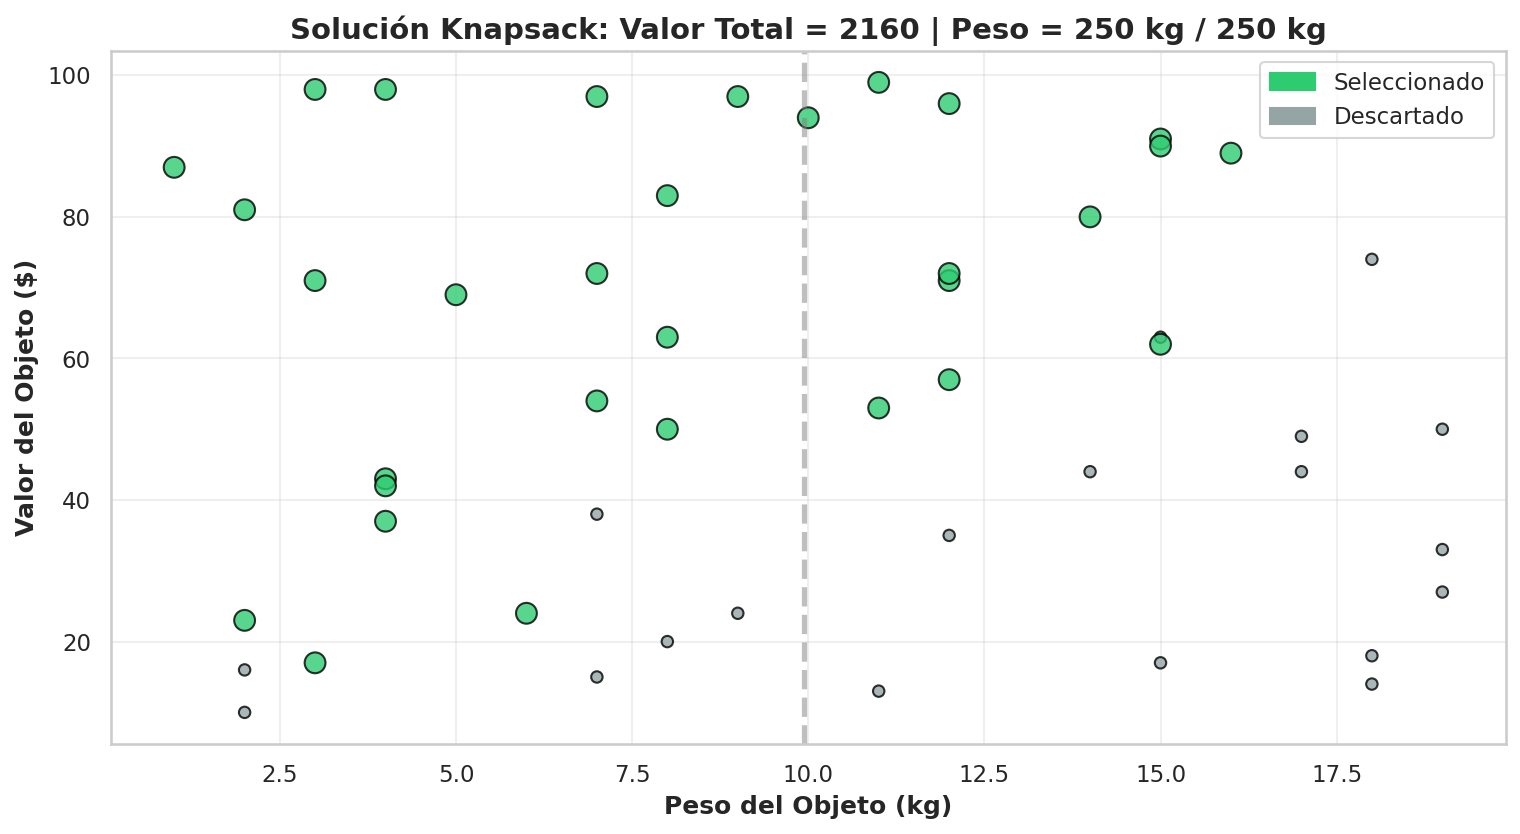

In [5]:
peso_final = np.sum(mejor_soft * pesos)
valor_final = np.sum(mejor_soft * valores)

colores = ['#2ecc71' if bit == 1 else '#95a5a6' for bit in mejor_soft]
tamanos = [100 if bit == 1 else 30 for bit in mejor_soft]

plt.figure(figsize=(12, 6))
plt.scatter(pesos, valores, c=colores, s=tamanos, alpha=0.8, edgecolor='black')
plt.axvline(x=np.mean(pesos), color='gray', linestyle='--', alpha=0.5)

# Anotaciones
plt.title(f"Solución Knapsack: Valor Total = {valor_final} | Peso = {peso_final} kg / {PESO_MAXIMO} kg")
plt.xlabel("Peso del Objeto (kg)")
plt.ylabel("Valor del Objeto ($)")

# Leyenda custom
import matplotlib.patches as mpatches
verde_patch = mpatches.Patch(color='#2ecc71', label='Seleccionado')
gris_patch = mpatches.Patch(color='#95a5a6', label='Descartado')
plt.legend(handles=[verde_patch, gris_patch])

plt.grid(True, alpha=0.3)
plt.show()

> *Nota de Ingeniería*: Observar cómo el algoritmo tiende a seleccionar los puntos que están en la zona superior izquierda (alto valor, bajo peso), demostrando que ha aprendido la heurística subyacente del problema.

In [6]:
peso_final_soft = np.sum(mejor_soft * pesos)
peso_final_hard = np.sum(mejor_hard * pesos)
print(f"--- Resultados del Knapsack Problem ---")
print("SOFT PENALTY")
print(f"Valor máximo encontrado: {mejor_soft.fitness.values[0]:.0f}")
print(f"Peso de la mochila: {peso_final_soft} kg (Límite: {PESO_MAXIMO} kg)")
print(f"Objetos seleccionados: {np.sum(mejor_soft)} de {N_OBJETOS}")
print()
print("HARD PENALTY")
print(f"Valor máximo encontrado: {mejor_hard.fitness.values[0]:.0f}")
print(f"Peso de la mochila: {peso_final_hard} kg (Límite: {PESO_MAXIMO} kg)")
print(f"Objetos seleccionados: {np.sum(mejor_hard)} de {N_OBJETOS}")

--- Resultados del Knapsack Problem ---
SOFT PENALTY
Valor máximo encontrado: 2160
Peso de la mochila: 250 kg (Límite: 250 kg)
Objetos seleccionados: 31 de 50

HARD PENALTY
Valor máximo encontrado: 2147
Peso de la mochila: 250 kg (Límite: 250 kg)
Objetos seleccionados: 32 de 50


## Parte II: Representación Permutacional y el TSP


### 1. El Problema del Viajante de Comercio (*TSP*)



Imaginemos ahora que somos un repartidor logístico. Tenemos que visitar $N$ ciudades exactamente una vez y volver al punto de partida, minimizando la distancia total recorrida (*esto hace alusión a tiempo/combustible gastado, por ejemplo. Cuestiones que se traducen directamente a la disminución de costos operativos.*).

* **Genotipo:** Una permutación de índices (ej. `[2, 0, 4, 1, 3]`).
* **Espacio de búsqueda:** $\frac{(N-1)!}{2}$. Para 30 ciudades, hay más combinaciones posibles que estrellas en el universo observable. La fuerza bruta es imposible.

Vamos a generar 30 ciudades con coordenadas aleatorias en un mapa 2D.

In [7]:
N_CIUDADES = 30

# Generamos coordenadas (x, y) para las ciudades
ciudades = np.random.rand(N_CIUDADES, 2) * 100

# Calculamos la matriz de distancias euclidianas
from scipy.spatial import distance_matrix
matriz_distancias = distance_matrix(ciudades, ciudades)

def evaluar_ruta(individuo):
    """Calcula la distancia total de la ruta, incluyendo el regreso al inicio."""
    distancia_total = 0
    for i in range(N_CIUDADES):
        ciudad_actual = individuo[i]
        # Si estamos en la última ciudad, volvemos a la primera (índice 0)
        ciudad_siguiente = individuo[(i + 1) % N_CIUDADES]
        distancia_total += matriz_distancias[ciudad_actual][ciudad_siguiente]

    # Retornamos una tupla (DEAP lo exige)
    return (distancia_total,)

### 2. El Problema de los Operadores Clásicos



¿Qué pasa si cruzamos dos rutas por la mitad usando el cruce clásico de 1 punto (`cxOnePoint`)?
* Padre 1: `[0, 1, 2 | 3, 4, 5]`
* Padre 2: `[5, 4, 3 | 2, 1, 0]`
* Hijo: `[0, 1, 2 | 2, 1, 0]` ❌ **¡Ruta Inválida!** Visitamos la ciudad 1 y 2 dos veces, y nunca visitamos la 3, 4 y 5.

Es decir, permitimos la generación de hijos inválidos. Si usáramos esto en DEAP, tendríamos que escribir una función de "reparación" muy costosa computacionalmente para evitar evaluaciones sobre soluciones candidatas que no tienen sentido. Para solucionar esto, usamos operadores que preservan la estructura de la permutación.

#### A. Cruce de Orden (*Order Crossover - OX*)


Copia un segmento aleatorio del Padre 1 al Hijo. Luego, rellena los espacios vacíos con las ciudades del Padre 2, en el orden en que aparecen, saltándose las que ya están incluidas. En DEAP, esto es `tools.cxOrdered`.



#### B. Mutación por Inversión (*2-opt intuition*)


En lugar de intercambiar dos ciudades al azar, **invertimos el orden de un segmento completo** de la ruta.  
*Intuición Geométrica:* Si una ruta tiene líneas que se cruzan formando una "X", invertir el segmento entre esos dos puntos "descruza" las líneas, reduciendo drásticamente la distancia.

In [8]:
def mutacion_inversion(individuo, indpb):
    """
    Invierte un segmento aleatorio de la ruta.
    Es mucho más efectivo para el TSP que simplemente intercambiar dos ciudades.
    """
    if random.random() < indpb:
        # Elegimos dos puntos de corte al azar
        size = len(individuo)
        a, b = random.sample(range(size), 2)
        if a > b:
            a, b = b, a
        # Invertimos el segmento in-place
        individuo[a:b+1] = reversed(individuo[a:b+1])
    return individuo,

### 3. Implementación en DEAP


In [9]:
for cls in ['FitnessMin', 'Individual']:
    if hasattr(creator, cls): delattr(creator, cls)

# ¡Atención! Ahora queremos MINIMIZAR la distancia, por lo que el peso es -1.0
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

tb_tsp = base.Toolbox()

# Generador: random.sample crea una permutación sin repeticiones de 0 a N-1
tb_tsp.register("indices", random.sample, range(N_CIUDADES), N_CIUDADES)
tb_tsp.register("individual", tools.initIterate, creator.Individual, tb_tsp.indices)
tb_tsp.register("population", tools.initRepeat, list, tb_tsp.individual)

# Operadores Especializados
tb_tsp.register("evaluate", evaluar_ruta)
tb_tsp.register("mate", tools.cxOrdered) # Order Crossover
tb_tsp.register("mutate", mutacion_inversion, indpb=0.2) # Nuestra mutación custom
tb_tsp.register("select", tools.selTournament, tournsize=3)

# Estadísticas
stats_tsp = tools.Statistics(key=lambda ind: ind.fitness.values[0])
stats_tsp.register("min", np.min)
stats_tsp.register("mean", np.mean)
hof_tsp = tools.HallOfFame(1)

# Guardamos una ruta aleatoria inicial para comparar después
pob_tsp = tb_tsp.population(n=200)
ruta_inicial = pob_tsp[0].copy()

# Ejecución (Le damos más generaciones porque el TSP es un problema duro)
pob_tsp, log_tsp = algorithms.eaSimple(pob_tsp, tb_tsp, cxpb=0.8, mutpb=0.3, ngen=400,
                                       stats=stats_tsp, halloffame=hof_tsp, verbose=False)

# Resultados
mejor_ruta = hof_tsp[0]
dist_inicial = evaluar_ruta(ruta_inicial)[0]
dist_final = mejor_ruta.fitness.values[0]
mejora_pct = ((dist_inicial - dist_final) / dist_inicial) * 100
print(f"--- Resultados del TSP ---")
print(f"Distancia de una ruta aleatoria inicial: {dist_inicial:.2f}")
print(f"Distancia de la ruta optimizada: {dist_final:.2f}")
print(f"Mejora del recorrido: {mejora_pct:.2f}%")

--- Resultados del TSP ---
Distancia de una ruta aleatoria inicial: 1533.74
Distancia de la ruta optimizada: 449.60
Mejora del recorrido: 70.69%


## Visualización y Resultados



Visualizamos "la magia" de la evolución. Graficamos la curva de convergencia y comparamos visualmente "la ensalada" de la ruta inicial contra el polígono limpio de la ruta optimizada.

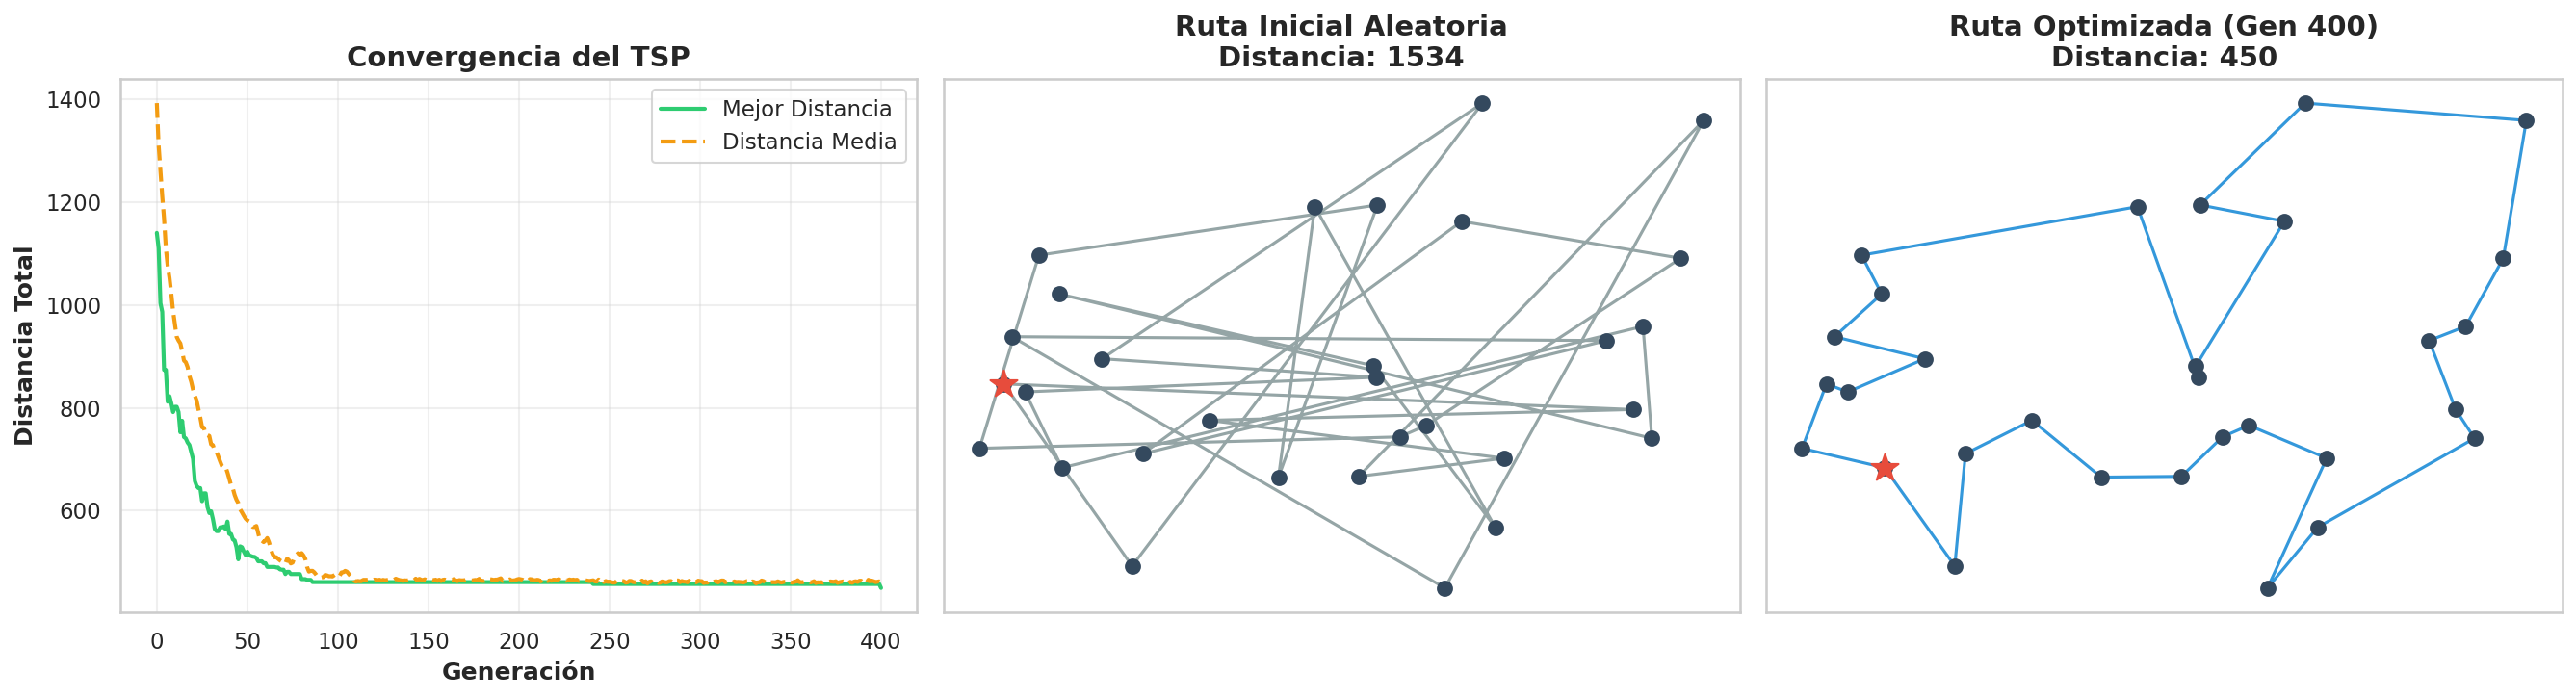

In [10]:
fig = plt.figure(figsize=(18, 5))

# 1. Curva de Convergencia
ax1 = fig.add_subplot(131)
gen = log_tsp.select("gen")
fit_min = log_tsp.select("min")
fit_mean = log_tsp.select("mean")

ax1.plot(gen, fit_min, label='Mejor Distancia', color='#2ecc71', lw=2)
ax1.plot(gen, fit_mean, label='Distancia Media', color='#f39c12', linestyle='--', lw=2)
ax1.set_title("Convergencia del TSP")
ax1.set_xlabel("Generación")
ax1.set_ylabel("Distancia Total")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Función auxiliar para dibujar rutas
def dibujar_ruta(ax, ruta, titulo, color_linea):
    # Reordenamos las coordenadas según la ruta
    coords_ruta = ciudades[ruta]
    # Añadimos la primera ciudad al final para cerrar el ciclo
    coords_ruta = np.vstack((coords_ruta, coords_ruta[0]))

    ax.plot(coords_ruta[:, 0], coords_ruta[:, 1], color=color_linea, lw=1.5, zorder=1)
    ax.scatter(ciudades[:, 0], ciudades[:, 1], color='#34495e', s=50, zorder=2)
    # Marcamos el inicio con una estrella
    ax.scatter(coords_ruta[0, 0], coords_ruta[0, 1], color='#e74c3c', marker='*', s=200, zorder=3, label='Inicio')

    ax.set_title(titulo)
    ax.set_xticks([])
    ax.set_yticks([])

# 2. Ruta Inicial Aleatoria
ax2 = fig.add_subplot(132)
dibujar_ruta(ax2, ruta_inicial, f"Ruta Inicial Aleatoria\nDistancia: {evaluar_ruta(ruta_inicial)[0]:.0f}", '#95a5a6')

# 3. Ruta Optimizada por el GA
ax3 = fig.add_subplot(133)
dibujar_ruta(ax3, mejor_ruta, f"Ruta Optimizada (Gen 400)\nDistancia: {mejor_ruta.fitness.values[0]:.0f}", '#3498db')

plt.tight_layout()
plt.show()

### Análisis de Resultados


* **La Curva de Convergencia:** Observar cómo la distancia cae en picada en las primeras 50 generaciones. El algoritmo rápidamente elimina los cruces más obvios. Luego, la curva se aplana, entrando en una fase de "ajuste fino" donde la mutación por inversión hace el trabajo pesado de desenredar pequeños nudos locales.
* **El Mapa:** La ruta inicial es un caos ineficiente. La ruta final, aunque quizás no sea el óptimo global absoluto (el TSP es NP-Hard), es una solución de altísima calidad, sin líneas que se crucen, lograda en apenas unos segundos de cómputo.

## Discusión de Ingeniería: Escalabilidad y el Mundo Real

Resolvimos un TSP de 30 ciudades en segundos. Pero, **¿qué tan escalable es esto?**

Con 30 ciudades ya tenemos $\approx 10^{32}$ posibles rutas. Para 100 ciudades, el espacio es astronómicamente grande. Los Algoritmos Genéticos dan soluciones de muy buena calidad, pero rara vez encuentran el óptimo global absoluto en problemas de esta magnitud por sí solos.

En la práctica industrial, los GAs rara vez operan aislados. Se combinan formando **Algoritmos Meméticos** o heurísticas híbridas:
- **Búsqueda Local:** Se corre un GA para encontrar una buena región global, y luego se aplica un algoritmo de búsqueda local (como *2-opt* o *3-opt* exhaustivo) sobre el mejor individuo para hacer el ajuste fino.
- **Hibridación:** GA + Simulated Annealing.
- **Exact Solvers:** Para instancias medianas, se usan solvers matemáticos exactos (como CPLEX o Gurobi) basados en *Column Generation*.

> Hay muchas opciones, la elección y combinación siempre depende de qué tanto se conozca el contexto del problema y el tipo de solución/error que se pretenda.



**Teaser Multiobjetivo:**  
Pensemos nuevamente en el problema de la mochila que resolvimos. Asumimos que el peso era una restricción estricta. Pero en la realidad, a veces queremos **Maximizar el Valor** y, a su vez, **Minimizar el Peso**, ambos simultáneamente. Esto ya no es un problema de un solo valor de *fitness*, sino de encontrar un *trade-off* (Frente de Pareto). Esto lo abordamos cuando veamos **NSGA-II** en un próximo notebook.

## Conexiones y Próximos Pasos


En este notebook cruzamos el puente hacia la ingeniería real. Vimos que el diseño del cromosoma (Binario vs. Permutacional) dicta qué operadores matemáticos se pueden usar, y que el manejo inteligente de restricciones (Penalización Suave) es vital para no destruir el gradiente de búsqueda.

Estas bases son fundamentales para los **Casos de Estudio** que abordamos en este capítulo:
* La codificación binaria que usamos en la mochila será la misma que usamos para hacer **Feature Selection** en modelos de Machine Learning.
* La lógica de penalizaciones es el núcleo para resolver el complejo **Nurse Scheduling Problem**, donde lidiamos con reglas de la institución y preferencias individuales para la programación de horarios/turnos del personal con restricciones duras y blandas.

Pero hay mucho más por abordar, volvemos a los espacios continuos para explorar dos paradigmas que superan al GA clásico en problemas matemáticos complejos.

- ➡️ **Siguiente:** [Estrategias Evolutivas (ES) y Evolución Diferencial (DE)](05_estrategias_evolutivas_y_de.ipynb)
- 🔄 **Relacionado:** [Introducción a DEAP: Infraestructura Evolutiva en Python](03_framework_deap_y_paralelizacion.ipynb). Disponible en los casos de estudio: [GA como Wrapper para Machine Learning (Feature Selection y HPO)](./casos_estudio/ga_machine_learning.ipynb)



## Referencias


### Artículos y Libros Fundacionales

1. **Davis, L. (1985)**. *Applying Adaptive Algorithms to Epistatic Domains*. IJCAI.  
   (Introdujo el Order Crossover - OX, uno de los operadores más usados en permutaciones).

2. **Lin, S. (1965)**. *Computer Solutions of the Traveling Salesman Problem*. Bell System Technical Journal.  
   (Fundamentos de la heurística 2-opt / inversión, base de muchas mutaciones en TSP).

3. **Michalewicz, Z. (1996)**. *Genetic Algorithms + Data Structures = Evolution Programs*. Springer.  
   (**Libro de referencia** para manejo de restricciones y representaciones en problemas combinatorios).

4. **Eiben, A. E., & Smith, J. E. (2015)**. *Introduction to Evolutionary Computing* (2nd ed.). Springer.  
   (Excelente capítulo sobre representaciones binarias y permutacionales).

### Recursos Prácticos

- **DEAP Documentation** — Ejemplo oficial de [Knapsack](https://deap.readthedocs.io/en/master/examples/ga_knapsack.html).
- **OR-Tools** de Google (para TSP y problemas de routing a escala industrial).


---


## Entorno de Ejecución


In [11]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
deap,1.4
ipywidgets,7.7.1
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
